In [ ]:
import os
os.listdir('/home/asagirova/arigraph/frontier-evals/project/paperbench/data/papers')

In [ ]:
str = ''
for pp in ['pinn',
 'bbox',
 'self-composing-policies',
 'self-expansion',
 'sample-specific-masks',
 'mechanistic-understanding',
 'adaptive-pruning',
 'rice',
 'all-in-one',
 'sequential-neural-score-estimation',
 'bam',
 'robust-clip',
 'ftrl',
 'what-will-my-model-forget',
 'stay-on-topic-with-classifier-free-guidance',
 'lca-on-the-line',
 'lbcs',
 'semantic-self-consistency']:
    str += f'python3 test_paper_reproduction.py --log-path cookbook_per_section_short_triplets_general_prompt_with_code --paper {pp}; '

str



'python3 test_paper_reproduction.py --log-path cookbook_per_section_short_triplets_general_prompt_with_code --paper pinn; python3 test_paper_reproduction.py --log-path cookbook_per_section_short_triplets_general_prompt_with_code --paper bbox; python3 test_paper_reproduction.py --log-path cookbook_per_section_short_triplets_general_prompt_with_code --paper self-composing-policies; python3 test_paper_reproduction.py --log-path cookbook_per_section_short_triplets_general_prompt_with_code --paper self-expansion; python3 test_paper_reproduction.py --log-path cookbook_per_section_short_triplets_general_prompt_with_code --paper sample-specific-masks; python3 test_paper_reproduction.py --log-path cookbook_per_section_short_triplets_general_prompt_with_code --paper mechanistic-understanding; python3 test_paper_reproduction.py --log-path cookbook_per_section_short_triplets_general_prompt_with_code --paper adaptive-pruning; python3 test_paper_reproduction.py --log-path cookbook_per_section_short_

In [1]:
import json
from pyvis.network import Network
import networkx as nx
from utils.utils import clear_triplet
import collections

Total nodes: 936
Total edges: 795

Number of connected components: 166
Component sizes:
[297, 158, 16, 9, 8, 8, 8, 8, 7, 7, 7, 6, 6, 6, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


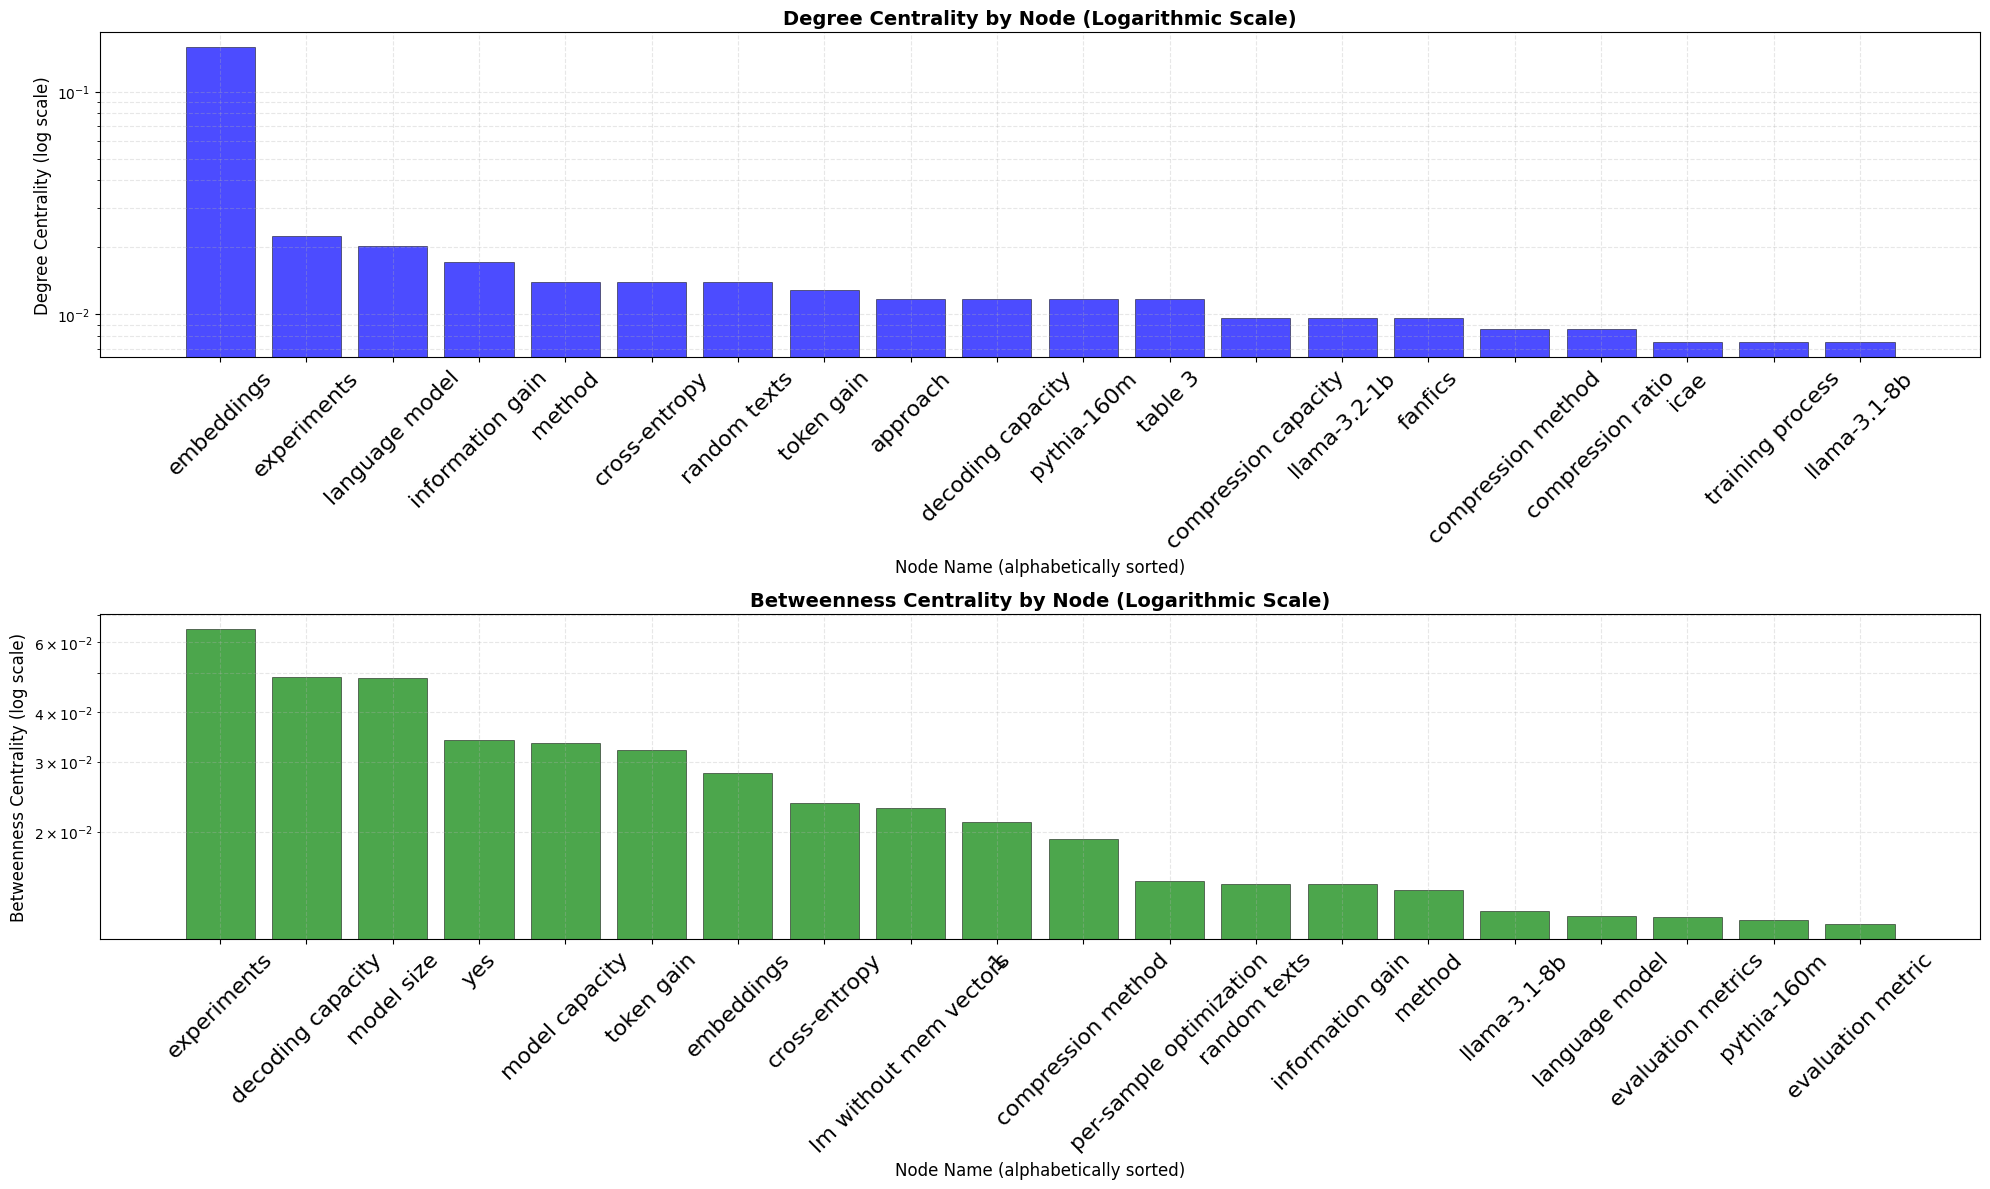

In [2]:
papers_path = '/home/asagirova/arigraph/without_code'
# /home/asagirova/arigraph/cookbook_per_section_short_triplets_general_prompt_with_code
papers = [
    'cram'
#'adaptive-pruning',
#'all-in-one',

    
    #'sapg', 
#'bridging-data-gaps', 
#'self-composing-policies', 'bbox',
# 'fre', 
#'mechanistic-understanding', 'pinn', 'sample-specific-masks', 
 #'test-time-model-adaptation',
]
for pp in papers:
    exp_path = f'{papers_path}/{pp}'
    #'/home/asagirova/arigraph/cookbook_per_section_short_triplets/bridging-data-gaps' #
    #'/home/asagirova/arigraph/cookbook_per_section_triplets/stochastic-interpolants'
    #'/home/asagirova/arigraph/cookbook_extraction_prompt'
    #'/home/asagirova/arigraph/reproduction_cookbook'

    with open(f'{exp_path}/graph_data.json',
        #'/home/asagirova/arigraph/reproduction_cookbook/reproduction_cookbook.json',
    'r') as f:

        file = json.load(f)
    triplets = file['triplets']

    all_nodes = []
    for i in triplets:
        all_nodes.extend(i[:2])
    all_nodes = set(all_nodes)
    code_nodes = []
    code_triplets = []
    for ff in file['code_stats']:
        for i in ff['triplets']:
            cleared = clear_triplet(i)
            code_triplets.append(cleared)
            code_nodes.extend(cleared[:2])
    code_nodes = set(code_nodes)

    text_nodes = []
    text_triplets = []
    for ff in file['sections']:
        
        for i in ff['triplets']:
            cleared = clear_triplet(i)
            text_triplets.append(cleared)
            text_nodes.extend(cleared[:2])
    text_nodes = set(text_nodes)
    common_nodes = text_nodes.intersection(code_nodes)

    # Build NetworkX graph from triplets
    G = nx.Graph()  # Use Graph for undirected, DiGraph for directed

    for s, o, r in triplets:
        G.add_edge(s, o, label=r['label'])
    
    print(f"Total nodes: {G.number_of_nodes()}")
    print(f"Total edges: {G.number_of_edges()}")

    # Find connected components
    components = list(nx.connected_components(G))
    print(f"\nNumber of connected components: {len(components)}")

    # Sort components by size (largest first)
    components_sorted = sorted(components, key=len, reverse=True)

    # Display component sizes
    print(f"Component sizes:\n{[len(component) for component in components_sorted]}")


    # Create a color palette for components
    import matplotlib.colors as mcolors
    colors = list(mcolors.TABLEAU_COLORS.values())
    if len(components_sorted) > len(colors):
        colors = list(mcolors.CSS4_COLORS.values())

    # Assign colors to nodes based on component
    component_map = {}
    for i, component in enumerate(components_sorted):
        color = colors[i % len(colors)]
        for node in component:
            component_map[node] = {'component_id': i, 'color': color}

    
    degree_cent = nx.degree_centrality(G)
    degree_cent = collections.OrderedDict(sorted(degree_cent.items(), key=lambda item: item[1], reverse=True))
    
    betweenness_cent = nx.betweenness_centrality(G,normalized=True)
    betweenness_cent = collections.OrderedDict(sorted(betweenness_cent.items(), key=lambda item: item[1], reverse=True))
    
    import matplotlib.pyplot as plt
    import numpy as np


    # Extract centrality values in the same order
    degree_values = list(degree_cent.values())
    betweenness_values = list(betweenness_cent.values())

    # Replace zeros with a small value to avoid log(0) errors
    min_nonzero_degree = min([v for v in degree_values if v > 0], default=1e-10)
    min_nonzero_betweenness = min([v for v in betweenness_values if v > 0], default=1e-10)

    degree_values_log = [max(v, min_nonzero_degree/10) for v in degree_values]
    betweenness_values_log = [max(v, min_nonzero_betweenness/10) for v in betweenness_values]

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 12))

    # Plot 1: Degree Centrality
    x_positions = np.arange(len(degree_cent.keys()))
    ax1.bar(x_positions[:20], degree_values_log[:20], alpha=0.7, color='blue', edgecolor='black', linewidth=0.5)
    ax1.set_yscale('log')
    ax1.set_xlabel('Node Name (alphabetically sorted)', fontsize=12)
    ax1.set_ylabel('Degree Centrality (log scale)', fontsize=12)
    ax1.set_title('Degree Centrality by Node (Logarithmic Scale)', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, which='both', linestyle='--')

    # Show only every Nth node name to avoid overlap
    #show_every_n = max(1, len(nodes_sorted) // 50)  # Show ~50 labels max
    ax1.set_xticks(x_positions[:20])
    ax1.set_xticklabels(list(degree_cent.keys())[:20], rotation=45, fontsize=16)

    # Plot 2: Betweenness Centrality
    x_positions = np.arange(len(betweenness_cent.keys()))
    ax2.bar(x_positions[:20], betweenness_values_log[:20], alpha=0.7, color='green', edgecolor='black', linewidth=0.5)
    ax2.set_yscale('log')
    ax2.set_xlabel('Node Name (alphabetically sorted)', fontsize=12)
    ax2.set_ylabel('Betweenness Centrality (log scale)', fontsize=12)
    ax2.set_title('Betweenness Centrality by Node (Logarithmic Scale)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, which='both', linestyle='--')

    ax2.set_xticks(x_positions[:20])
    ax2.set_xticklabels(list(betweenness_cent.keys())[:20], rotation=45, fontsize=16)

    plt.tight_layout()
    plt.show()




In [8]:
papers = ['adaptive-pruning',
    #'sapg', 
#'bridging-data-gaps', 
#'self-composing-policies', 'bbox',
# 'fre', 
#'mechanistic-understanding', 'pinn', 'sample-specific-masks', 
 #'test-time-model-adaptation',
]
for pp in papers:
    print(pp, '\n')
    exp_path = f'/home/asagirova/arigraph/cookbook_per_section_short_triplets_general_prompt_with_code/{pp}'
    #'/home/asagirova/arigraph/cookbook_per_section_short_triplets/bridging-data-gaps' #
    #'/home/asagirova/arigraph/cookbook_per_section_triplets/stochastic-interpolants'
    #'/home/asagirova/arigraph/cookbook_extraction_prompt'
    #'/home/asagirova/arigraph/reproduction_cookbook'

    with open(f'{exp_path}/graph_data.json',
        #'/home/asagirova/arigraph/reproduction_cookbook/reproduction_cookbook.json',
    'r') as f:

        file = json.load(f)
    triplets = file['triplets']

    all_nodes = []
    for i in triplets:
        all_nodes.extend(i[:2])
    all_nodes = set(all_nodes)
    code_nodes = []
    code_triplets = []
    for ff in file['code_stats']:
        for i in ff['triplets']:
            cleared = clear_triplet(i)
            code_triplets.append(cleared)
            code_nodes.extend(cleared[:2])
    code_nodes = set(code_nodes)

    text_nodes = []
    text_triplets = []
    for ff in file['sections']:
        
        for i in ff['triplets']:
            cleared = clear_triplet(i)
            text_triplets.append(cleared)
            text_nodes.extend(cleared[:2])
    text_nodes = set(text_nodes)
    common_nodes = text_nodes.intersection(code_nodes)

    # Build NetworkX graph from triplets
    G = nx.Graph()  # Use Graph for undirected, DiGraph for directed

    for s, o, r in triplets:
        G.add_edge(s, o, label=r['label'])
    
    print(f"Total nodes: {G.number_of_nodes()}")
    #print(f"Total edges: {G.number_of_edges()}")

    # Find connected components
    components = list(nx.connected_components(G))
    #print(f"\nNumber of connected components: {len(components)}")

    # Sort components by size (largest first)
    components_sorted = sorted(components, key=len, reverse=True)

    # Display component sizes
    #print(f"Component sizes:\n{[len(component) for component in components_sorted]}")

    all_nodes = []
    for i in triplets:
        all_nodes.extend(i[:2])
    all_nodes = set(all_nodes)
    code_nodes = []
    code_triplets = []
    for ff in file['code_stats']:
        for i in ff['triplets']:
            cleared = clear_triplet(i)
            code_triplets.append(cleared)
            code_nodes.extend(cleared[:2])
    code_nodes = set(code_nodes)

    text_nodes = []
    text_triplets = []
    for ff in file['sections']:
        
        for i in ff['triplets']:
            cleared = clear_triplet(i)
            text_triplets.append(cleared)
            text_nodes.extend(cleared[:2])
    text_nodes = set(text_nodes)
    common_nodes = text_nodes.intersection(code_nodes)

    #print(f"text nodes {len(text_nodes)},code nodes {len(code_nodes)}")
    # big connectivity component
    nodes_from_text = 0
    nodes_from_code = 0
    nodes_from_common = 0
    sum_nodes = 0
    for i in components_sorted[:1]:
        #print(list(i)[:20])
        sum_nodes += len(i)
        nodes_from_text += len(i.intersection(text_nodes))
        nodes_from_code += len(i.intersection(code_nodes))
        nodes_from_common += len(i.intersection(common_nodes))
        #print(f"{len(i)} from text/code/common:{len(i.intersection(text_nodes))}/{len(i.intersection(code_nodes))}/{len(i.intersection(common_nodes))}") #
        #print('====================================')
    print(f"big connectivity component:    nodes_from_text ={nodes_from_text}/{sum_nodes}, nodes_from_code ={nodes_from_code}/{sum_nodes}, nodes_from_common {nodes_from_common}/{sum_nodes}")

    # small connectivity components
    nodes_from_text = 0
    nodes_from_code = 0
    nodes_from_common = 0
    sum_nodes = 0
    for i in components_sorted[1:]:
        #print(list(i)[:20])
        sum_nodes += len(i)
        nodes_from_text += len(i.intersection(text_nodes))
        nodes_from_code += len(i.intersection(code_nodes))
        nodes_from_common += len(i.intersection(common_nodes))
        #print(f"{len(i)} from text/code/common:{len(i.intersection(text_nodes))}/{len(i.intersection(code_nodes))}/{len(i.intersection(common_nodes))}") #
        #print('====================================')
    print(f"small connectivity components: nodes_from_text ={nodes_from_text}/{sum_nodes}, nodes_from_code ={nodes_from_code}/{sum_nodes}, nodes_from_common {nodes_from_common}/{sum_nodes}")


adaptive-pruning 

Total nodes: 10532
big connectivity component:    nodes_from_text =956/9493, nodes_from_code =8662/9493, nodes_from_common 125/9493
small connectivity components: nodes_from_text =201/1039, nodes_from_code =839/1039, nodes_from_common 1/1039


In [ ]:
# Build NetworkX graph from triplets
G = nx.Graph()  # Use Graph for undirected, DiGraph for directed

for s, o, r in triplets:
    G.add_edge(s, o, label=r['label'])

print(f"Total nodes: {G.number_of_nodes()}")
print(f"Total edges: {G.number_of_edges()}")

# Find connected components
components = list(nx.connected_components(G))
print(f"\nNumber of connected components: {len(components)}")

# Sort components by size (largest first)
components_sorted = sorted(components, key=len, reverse=True)

# Display component sizes
print(f"Component sizes:\n{[len(component) for component in components_sorted]}")


# Create a color palette for components
import matplotlib.colors as mcolors
colors = list(mcolors.TABLEAU_COLORS.values())
if len(components_sorted) > len(colors):
    colors = list(mcolors.CSS4_COLORS.values())

# Assign colors to nodes based on component
component_map = {}
for i, component in enumerate(components_sorted):
    color = colors[i % len(colors)]
    for node in component:
        component_map[node] = {'component_id': i, 'color': color}

Total nodes: 6651
Total edges: 8335

Number of connected components: 481
Component sizes:
[5318, 60, 24, 16, 14, 11, 11, 9, 9, 9, 9, 8, 8, 7, 7, 7, 7, 7, 7, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 

In [24]:
len(all_nodes),len(text_nodes),len(code_nodes), len(common_nodes)

(3093, 1859, 1405, 172)

In [25]:
len(all_nodes.intersection(text_nodes)), len(all_nodes.intersection(code_nodes)), len(all_nodes.intersection(common_nodes))

(1859, 1405, 172)

In [17]:
degree_cent = nx.degree_centrality(G)
cent = nx.betweenness_centrality(G,normalized=True)
#print(cent)

In [ ]:


def top_central_nodes(centrality, type='', top=10):
    sorted_cent = collections.OrderedDict(sorted(centrality.items(), key=lambda item: item[1], reverse=True))
    i = 0
    print(f"\n{type} centrality")
    for k,v in sorted_cent.items():
        i += 1
        print((k,v))
        if i > top:
            break

In [19]:
top_central_nodes(degree_cent, type='degree', top=10)
top_central_nodes(cent, type='betweenness', top=10)


degree centrality
('sync', 0.13999999999999999)
('continuousmountaincarlstm', 0.03969924812030075)
('policy', 0.03789473684210526)
('config', 0.03007518796992481)
('true', 0.021654135338345863)
('env', 0.016541353383458645)
('false', 0.015488721804511277)
('sapg', 0.015037593984962405)
('tensor', 0.012030075187969924)
('1', 0.0118796992481203)
('ppo', 0.01112781954887218)

betweenness centrality
('true', 0.2223477984177382)
('sync', 0.2211893324684399)
('config', 0.0862394596683914)
('continuousmountaincarlstm', 0.07962016731772428)
('policy', 0.062192573090921875)
('env', 0.061031738936869966)
('ppo', 0.04871485241363798)
('mlp', 0.04587707868516808)
('tensor', 0.03988036263491777)
('1', 0.03311757342625229)
('false', 0.02891705652979291)


In [27]:
# big connectivity component
nodes_from_text = 0
nodes_from_code = 0
nodes_from_common = 0
sum_nodes = 0
for i in components_sorted[:1]:
    #print(list(i)[:20])
    sum_nodes += len(i)
    nodes_from_text += len(i.intersection(text_nodes))
    nodes_from_code += len(i.intersection(code_nodes))
    nodes_from_common += len(i.intersection(common_nodes))
    #print(f"{len(i)} from text/code/common:{len(i.intersection(text_nodes))}/{len(i.intersection(code_nodes))}/{len(i.intersection(common_nodes))}") #
    #print('====================================')
print(f"big connectivity component:    nodes_from_text {nodes_from_text}/{sum_nodes}, nodes_from_code {nodes_from_code}/{sum_nodes}, nodes_from_common {nodes_from_common}/{sum_nodes}")

# small connectivity components
nodes_from_text = 0
nodes_from_code = 0
nodes_from_common = 0
sum_nodes = 0
for i in components_sorted[1:]:
    #print(list(i)[:20])
    sum_nodes += len(i)
    nodes_from_text += len(i.intersection(text_nodes))
    nodes_from_code += len(i.intersection(code_nodes))
    nodes_from_common += len(i.intersection(common_nodes))
    #print(f"{len(i)} from text/code/common:{len(i.intersection(text_nodes))}/{len(i.intersection(code_nodes))}/{len(i.intersection(common_nodes))}") #
    #print('====================================')
print(f"small connectivity components: nodes_from_text {nodes_from_text}/{sum_nodes}, nodes_from_code {nodes_from_code}/{sum_nodes}, nodes_from_common {nodes_from_common}/{sum_nodes}")

big connectivity component:    nodes_from_text 1736/2751, nodes_from_code 1184/2751, nodes_from_common 170/2751
small connectivity components: nodes_from_text 123/342, nodes_from_code 221/342, nodes_from_common 2/342


In [5]:
def vis_net(subgraph, exp_path, save_as=''):
    """
    Visualize graph with multiple connected components properly separated.
    Each component is positioned independently to prevent overlap.
    """
    import math
    # Find connected components within the subgraph
    components = list(nx.connected_components(subgraph))
    num_comps = len(components)
    
    # Create pyvis network
    net = Network(
        height="1000px",
        width="100%",
        bgcolor="#ffffff",
        font_color='#10000000' if num_comps < 2 else "black",
        directed=True,
    )

    import matplotlib.colors as mcolors
    colors = list(mcolors.TABLEAU_COLORS.values())
    if len(components) > len(colors):
        colors = list(mcolors.CSS4_COLORS.values())

    # Assign colors to nodes based on component
    component_map = {}
    for i, component in enumerate(components):
        color = colors[i % len(colors)]
        for node in component:
            component_map[node] = {'component_id': i, 'color': color}

    # Calculate layout for each component separately with proper spacing
    all_positions = {}
    component_spacing = 2000  # Space between components
    
    # Arrange components in a grid layout
    grid_cols = math.ceil(math.sqrt(len(components)))
    
    for idx, component in enumerate(components):
        # Create subgraph for this component
        comp_subgraph = subgraph.subgraph(component)
        
        # Choose layout algorithm based on component size
        if len(component) < 30:
            # For small components, use spring layout
            pos = nx.spring_layout(comp_subgraph, k=2, iterations=50, scale=500)
        elif len(component) < 100:
            # For medium components, use spring layout with more space
            pos = nx.spring_layout(comp_subgraph, k=1.5, iterations=50, scale=800)
        else:
            # For large components, use kamada_kawai or spring with large scale
            try:
                pos = nx.kamada_kawai_layout(comp_subgraph, scale=1000)
            except:
                pos = nx.spring_layout(comp_subgraph, k=1, iterations=50, scale=1000)
        
        # Calculate offset for this component in the grid
        row = idx // grid_cols
        col = idx % grid_cols
        offset_x = col * component_spacing
        offset_y = row * component_spacing
        
        # Apply offset to separate components
        for node, (x, y) in pos.items():
            all_positions[node] = (x + offset_x, y + offset_y)
    
    # Add nodes with fixed positions
    for node in subgraph.nodes():
        x, y = all_positions[node]
        net.add_node(
            node,
            label=node,
            title=node,
            color=component_map[node]['color'],
            shape='dot',
            size=10,
            x=x,
            y=y,
            physics=False,  # Fix position
        )

    # Add edges
    for s, o, edge_data in subgraph.edges(data=True):
        net.add_edge(
            s, o, 
            label=edge_data.get('label', ''),
            title=edge_data.get('label', ''),
        )
    
    # Disable physics since we have fixed positions
    net.toggle_physics(False)
    
    # Set options for better visualization
    net.set_options("""
    {
      "nodes": {
        "font": {
          "size": 12
        }
      },
      "edges": {
        "color": {
          "inherit": false,
          "color": "#848484"
        },
        "smooth": {
          "type": "continuous"
        },
        "arrows": {
          "to": {
            "enabled": true,
            "scaleFactor": 0.5
          }
        },
        "font": {
          "size": 10,
          "align": "middle"
        }
      },
      "physics": {
        "enabled": false
      },
      "interaction": {
        "hover": true,
        "tooltipDelay": 100,
        "navigationButtons": true,
        "keyboard": true
      }
    }
    """)

    # Save and display
    filename = f'{exp_path}/{save_as}.html'
    net.show(filename, notebook=False)

In [12]:
comps_to_join = set()
for idx in range(len(components_sorted)):
    component = components_sorted[idx]
    if len(component) > 100:
        subgraph = G.subgraph(component).copy()
        vis_net(subgraph, exp_path, save_as=f'comp{idx+1}_{len(component)}nodes')
    else:
        comps_to_join = comps_to_join.union(component)
if len(comps_to_join) > 0:
    subgraph = G.subgraph(comps_to_join).copy()
    vis_net(subgraph, exp_path, save_as=f'small_comps_{len(comps_to_join)}nodes')

/home/asagirova/arigraph/cookbook_per_section_short_triplets/bridging-data-gaps/comp1_2419nodes.html
/home/asagirova/arigraph/cookbook_per_section_short_triplets/bridging-data-gaps/small_comps_213nodes.html


In [ ]:
# Create a single network showing all components with different colors
net_all = Network(
    height="1500px", width="1900px", 
    bgcolor="#222222", font_color="white", 
    directed=True
)
net_all.from_nx(G, default_node_size=30)
net.toggle_physics(False) # Turn off physics to prevent hanging

# Show the complete graph
net_all.show(f'{exp_path}/full_graph_colored.html', notebook=False)

/home/asagirova/arigraph/cookbook_per_section_triplets/stochastic-interpolants/full_graph_colored.html


In [ ]:
# Test the improved vis_net function
# Visualize just the small components to see how multiple components are separated
print(f"Testing visualization with multiple small components...")
small_components = [c for c in components_sorted if len(c) < 100 and len(c) >= 3]
print(f"Found {len(small_components)} components with 3-100 nodes")

# Take first 10 small components and combine them
test_nodes = set()
for comp in small_components[:10]:
    test_nodes.update(comp)

test_subgraph = G.subgraph(test_nodes).copy()
print(f"Combined subgraph has {test_subgraph.number_of_nodes()} nodes")
vis_net(test_subgraph, component_map, exp_path, save_as='test_multiple_components')

In [ ]:
# Helper function to visualize specific components by index
def visualize_components_by_index(G, component_map, exp_path, indices, save_as='selected_components'):
    """
    Visualize specific components by their indices.
    
    Args:
        G: NetworkX graph
        component_map: Dictionary mapping nodes to component info
        exp_path: Path to save HTML file
        indices: List of component indices (0-based)
        save_as: Filename for saved visualization
    """
    components = list(nx.connected_components(G))
    components_sorted = sorted(components, key=len, reverse=True)
    
    # Collect nodes from selected components
    selected_nodes = set()
    for idx in indices:
        if idx < len(components_sorted):
            selected_nodes.update(components_sorted[idx])
        else:
            print(f"Warning: Component index {idx} out of range (max: {len(components_sorted)-1})")
    
    if selected_nodes:
        subgraph = G.subgraph(selected_nodes).copy()
        print(f"Visualizing {len(indices)} component(s) with {len(selected_nodes)} total nodes")
        vis_net(subgraph, component_map, exp_path, save_as=save_as)
    else:
        print("No valid components selected")

# Example: Visualize components 2, 3, 4, 5 (0-indexed)
# visualize_components_by_index(G, component_map, exp_path, [2, 3, 4, 5], 'components_2to5')

In [ ]:
# Configuration options for the vis_net function
# You can modify these in the function definition if needed:

CONFIG_OPTIONS = """
Component Spacing Options:
- component_spacing = 2000  # Distance between components (increase for more separation)

Layout Algorithm Selection:
- Small (<30 nodes): spring_layout with k=2, scale=500
- Medium (30-100): spring_layout with k=1.5, scale=800  
- Large (>100): kamada_kawai_layout with scale=1000

Grid Arrangement:
- Components arranged in sqrt(n) x sqrt(n) grid
- Modify grid_cols calculation to change layout pattern

Node Appearance:
- shape='dot' (can change to 'circle', 'box', 'diamond', etc.)
- size=10 (node size)
- physics=False (keeps positions fixed)

Customization Example:
To increase spacing between components, change in vis_net():
  component_spacing = 3000  # or higher
"""

print(CONFIG_OPTIONS)

In [ ]:
# Summary: Revised vis_net Function
# 
# Key Improvements:
# 1. Automatic Component Separation - detects and separates connected components
# 2. Grid Layout - arranges components in sqrt(n) x sqrt(n) grid to prevent overlap
# 3. Adaptive Algorithms - uses appropriate layout based on component size
# 4. Fixed Positions - all nodes have fixed positions (no overlapping)
# 5. Enhanced Interactivity - tooltips, navigation buttons, hover effects
#
# Usage Examples:
#   vis_net(subgraph, component_map, exp_path, save_as='my_graph')
#   visualize_components_by_index(G, component_map, exp_path, [0,1,2], 'top_3')
#
# Customization: Edit component_spacing, layout parameters, or grid_cols in vis_net()

In [6]:
net = Network(
        #height="600px",
        width="100%",
        #bgcolor="#ffffff",
        #font_color="white",
        directed=True,
        notebook=True,
)
highlight_entities = set()
added_nodes = set()

for s, o, r in triplets:
    for node in [s, o]:
        if node not in added_nodes:
            net.add_node(
                node,
                label=node,
                title=r['label'],
                shape='point',
                #color="#B2CD9C" if node in highlight_entities else "#C7C8CC",
            )
            added_nodes.add(node)
    net.add_edge(s, o, label=r['label'], #color="#000000"
    )
net.show('arigraph.html')
'''
with tempfile.NamedTemporaryFile(delete=False, suffix=".html") as tmp_file:
    net.save_graph(tmp_file.name)
    html_path = tmp_file.name
with open(html_path, "r", encoding="utf-8") as f:

    st.components.v1.html(f.read(), height=600, scrolling=True)
os.remove(html_path)
'''

arigraph.html


'\nwith tempfile.NamedTemporaryFile(delete=False, suffix=".html") as tmp_file:\n    net.save_graph(tmp_file.name)\n    html_path = tmp_file.name\nwith open(html_path, "r", encoding="utf-8") as f:\n\n    st.components.v1.html(f.read(), height=600, scrolling=True)\nos.remove(html_path)\n'